# Empty drops

In [3]:
library(SingleCellExperiment)
library(data.table)
library(Matrix)
library(EmptyDropsMultiome)
library(ggplot2)
library(dplyr)

Warning message:
“package ‘data.table’ was built under R version 4.4.2”

Attaching package: ‘data.table’


The following object is masked from ‘package:SummarizedExperiment’:

    shift


The following object is masked from ‘package:GenomicRanges’:

    shift


The following object is masked from ‘package:IRanges’:

    shift


The following objects are masked from ‘package:S4Vectors’:

    first, second


Warning message:
“package ‘Matrix’ was built under R version 4.4.3”

Attaching package: ‘Matrix’


The following object is masked from ‘package:S4Vectors’:

    expand



Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following object is masked from ‘package:Biobase’:

    combine


The following objects are masked from ‘package:GenomicRanges’:

    intersect, setdiff, union


The following object is masked from ‘package:GenomeInfoDb’:

    intersect


The following objects are masked from ‘package:IRanges’:

 

In [10]:
io = list()
io$home = '/rds/project/rds-SDzz0CATGms/users/bt392/'

io$datadir = sprintf('%s/09_Eomes_invitro_blood/original/', io$home)

In [7]:
opts = list()
opts$samples <- c(
  # first batch
  "rv_eo_deg_day3_5_control",
  "rv_eo_deg_day3_5_dtag",
  "rv_eo_deg_day4_5_control",
  "rv_eo_deg_day4_5_dtag",
  "rv_eo_deg_day4_control",
  "rv_eo_deg_day4_dtag",

  # second batch
  "1A_Eo_DEG_G9_day3",
  "1B_Eo_DEG_G9_day3",
  "2_Eo_DEG_G9_day3_5_dTAG",
  "2_Eo_DEG_G9_day3_5_VC",
  "2_Eo_DEG_G9_day4_dTAG",
  "2_Eo_DEG_G9_day4_VC",
  "2_Eo_DEG_G9_day5_dTAG",
  "2_Eo_DEG_G9_day5_VC"
)

In [6]:
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 42

In [5]:
emptydrops_with_barhop <- function(count_matrix, lower, barhop_end, niters=10000, seed=42){
  # calls cells using a single modality
  # inputs: count_matrix is a features-by-cell matrix,
  #         lower is the upper bound on the count for a droplet to be used to model the soup
  #         barhop_end is the lower bound on the count for a droplet to be used to model the soup
  # outputs: dataframe like e.out


  # subset out the barhops from count matrix to feed it into emptydrops

  barhops <- Matrix::colSums(count_matrix)<barhop_end
  counts_wo_barhop <- count_matrix[, !barhops]
  if (!length(colnames(count_matrix))==0){
    barhop_names <- colnames(count_matrix)[barhops]
  }else{
    barhop_names <- NULL
  }

  # run emptyrdops on counts_wo_barhop
  set.seed(seed)
  e.out <- DropletUtils::emptyDrops(counts_wo_barhop, lower=lower, niters=niters, test.ambient=TRUE, BPPARAM = BPPARAM)

  # create df with NA for barhops
  totals_barhop <- Matrix::colSums(count_matrix)[barhops]
  totals_barhop <- unname(totals_barhop)
  all.lr_barhops <- rep(as.numeric(NA), sum(barhops))
  all.p_barhops <- rep(as.numeric(NA), sum(barhops))
  all.lim_barhops <- rep(as.numeric(NA), sum(barhops))
  fdr_barhop <- rep(as.numeric(NA), sum(barhops))

  barhop_output <- S4Vectors::DataFrame(Total=totals_barhop, LogProb=all.lr_barhops, PValue=all.p_barhops, Limited=all.lim_barhops, row.names=barhop_names, FDR=fdr_barhop)

  # merge the two dfs
  eD.out <- rbind(barhop_output, e.out)

  eD.out["barhop_amb_tent"] <- as.numeric(eD.out$Total<barhop_end) + as.numeric(eD.out$Total<=lower) + as.numeric(eD.out$Total>lower) *3

  return(eD.out)
}

rv_eo_deg_day3_5_control

rv_eo_deg_day3_5_dtag

rv_eo_deg_day4_5_control

rv_eo_deg_day4_5_dtag

rv_eo_deg_day4_control

rv_eo_deg_day4_dtag

1A_Eo_DEG_G9_day3

1B_Eo_DEG_G9_day3

2_Eo_DEG_G9_day3_5_dTAG

2_Eo_DEG_G9_day3_5_VC

2_Eo_DEG_G9_day4_dTAG



number of iterations= 37 
[1] "the mu's are : 25, 200, 1000"
[1] "the sigma's are : 1, 60, 300"
[1] "the lambdas are : 0.869565217391304, 0.0869565217391304, 0.0434782608695652"
[1] "equil point is 29.5675520080384"
[1] "the lower is : 290"
[1] "the rna lower is 290"
[1] "the rna barhop is 29.5675520080384"
number of iterations= 12 
[1] "the mu's are : 5.32619552985102, 335.022378932238, 52369.1327255073"
[1] "the sigma's are : 4.81654061634563, 307.55110732358, 59330.3979724967"
[1] "the lambdas are : 0.938186990696611, 0.0548004074598634, 0.0070126018435241"
[1] "equil point is 23.990794128143"
[1] "the lower is : 950.124593579398"


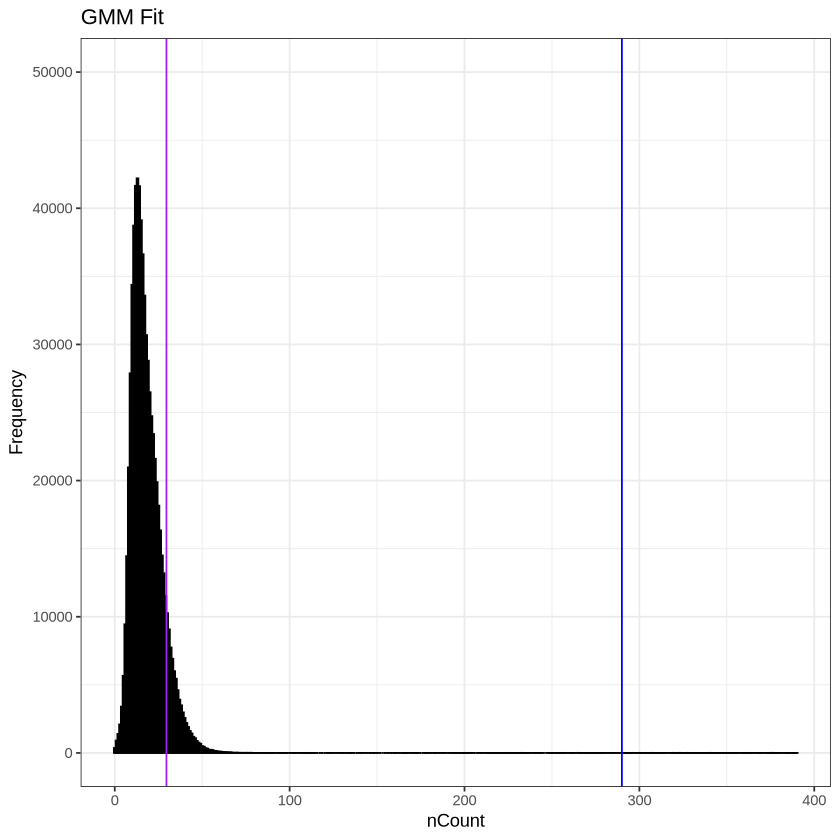

[1] "the atac lower is 950.124593579398"
[1] "the atac barhop is 23.990794128143"
[1] "Call cells using cellranger-arc"
[1] "finished ordering"
[1] "calculated keep"
[1] "thresholds are 13421.306" "thresholds are 2288.234" 
[1] "the means of the two clusters are: "
  rna_count atac_count
1  1.909044   2.488796
2  4.046966   4.802584
[1]  6.467310 -1.017312
[1] "rownames"   "atac_count" "rna_count"  "excluded"   "is_cell"   
[6] "dup"       
[1] "finished label transfer"
[1] "The number of cells called by k-means is "
[1] "4271 cells"
[1] "the tip has rna count  "
[1] 3.85519
[1] "the tip has atac count  "
[1] 4.566494
[1] "equation_parallel"
[1]  7.814720 -1.017312
[1] "equation"
[1]  6.467310 -1.017312
[1]  7.814720 -1.017312
[1] "lower_line"
[1]  5.491926 -1.017312


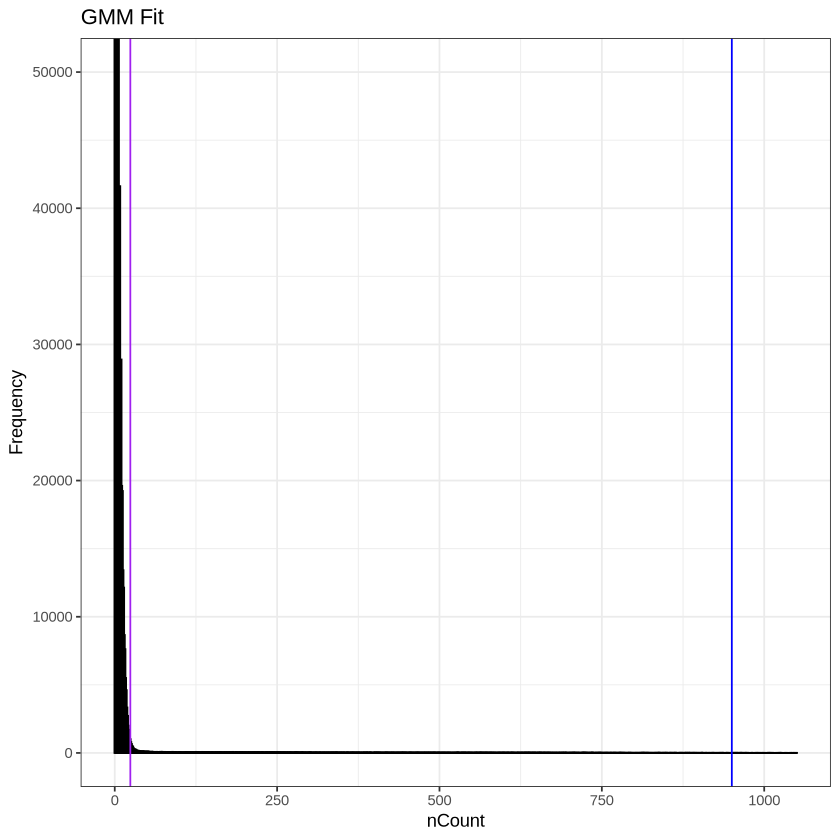

[1] "the number of cells detected is: "
[1] 4275
[1] "saving data"
Time difference of 1.393236 hours


2_Eo_DEG_G9_day4_VC

2_Eo_DEG_G9_day5_dTAG



number of iterations= 28 
[1] "the mu's are : 18.9877198540079, 358.690102924725, 12251.1476370371"
[1] "the sigma's are : 8.33705575293159, 165.042918903825, 10848.6659603245"
[1] "the lambdas are : 0.979562612459489, 0.0180023134865251, 0.00243507405398627"
[1] "equil point is 53.7424933142188"
[1] "the lower is : 606.254481280462"


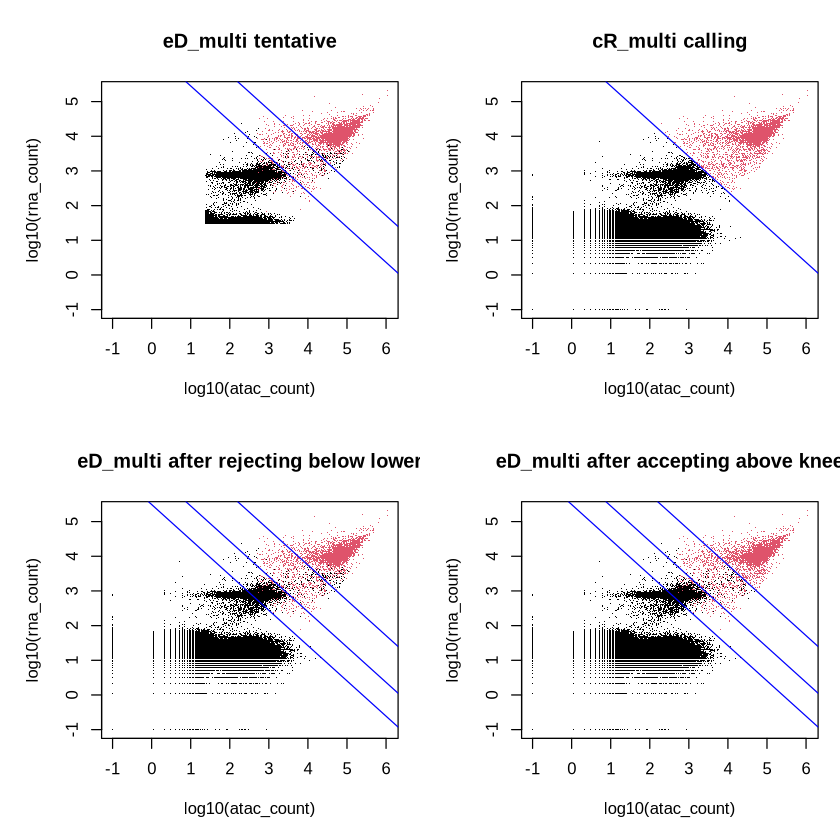

[1] "the rna lower is 606.254481280462"
[1] "the rna barhop is 53.7424933142188"
number of iterations= 12 
[1] "the mu's are : 2.19192529348298, 203.922097286492, 40122.4859714214"
[1] "the sigma's are : 2.50316089058294, 191.626945819951, 55856.8822820474"
[1] "the lambdas are : 0.934486799656634, 0.062256486412347, 0.00325671393101923"
[1] "equil point is 11.9180507816876"
[1] "the lower is : 587.175988926394"


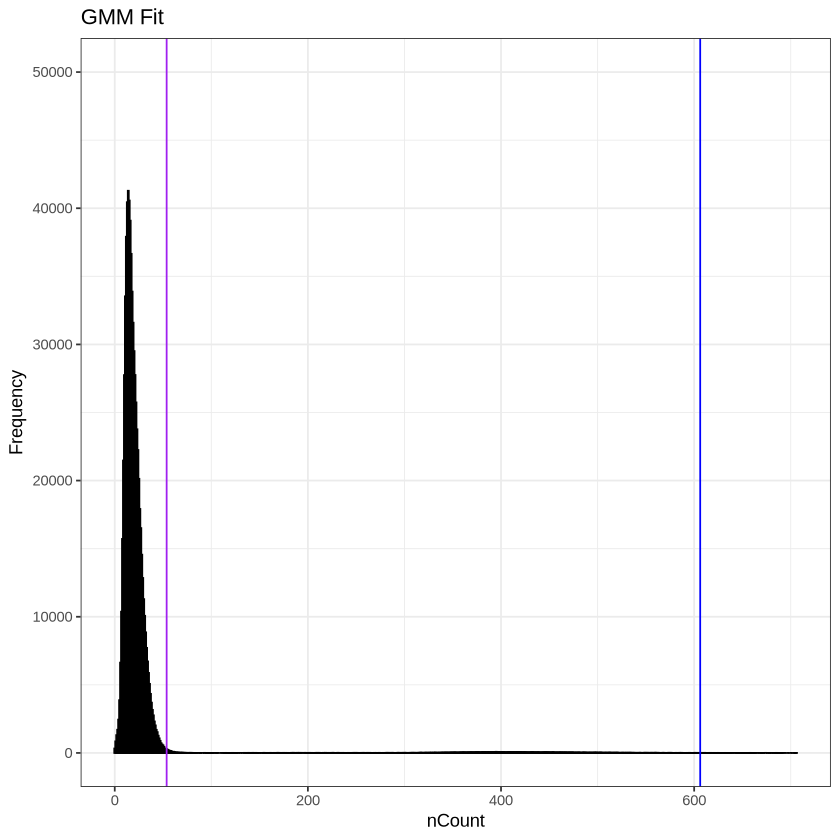

[1] "the atac lower is 587.175988926394"
[1] "the atac barhop is 11.9180507816876"
[1] "Call cells using cellranger-arc"
[1] "finished ordering"
[1] "calculated keep"
[1] "thresholds are 9531.332"         "thresholds are 1838.09499999999"
[1] "the means of the two clusters are: "
  rna_count atac_count
1  1.885295   2.320114
2  4.084948   4.755194
[1]  6.418411 -1.022615
[1] "rownames"   "atac_count" "rna_count"  "excluded"   "is_cell"   
[6] "dup"       
[1] "finished label transfer"
[1] "The number of cells called by k-means is "
[1] "1648 cells"
[1] "the tip has rna count  "
[1] 3.521879
[1] "the tip has atac count  "
[1] 4.124079
[1] "equation_parallel"
[1]  7.289875 -1.022615
[1] "equation"
[1]  6.418411 -1.022615
[1]  7.289875 -1.022615
[1] "lower_line"
[1]  5.614187 -1.022615


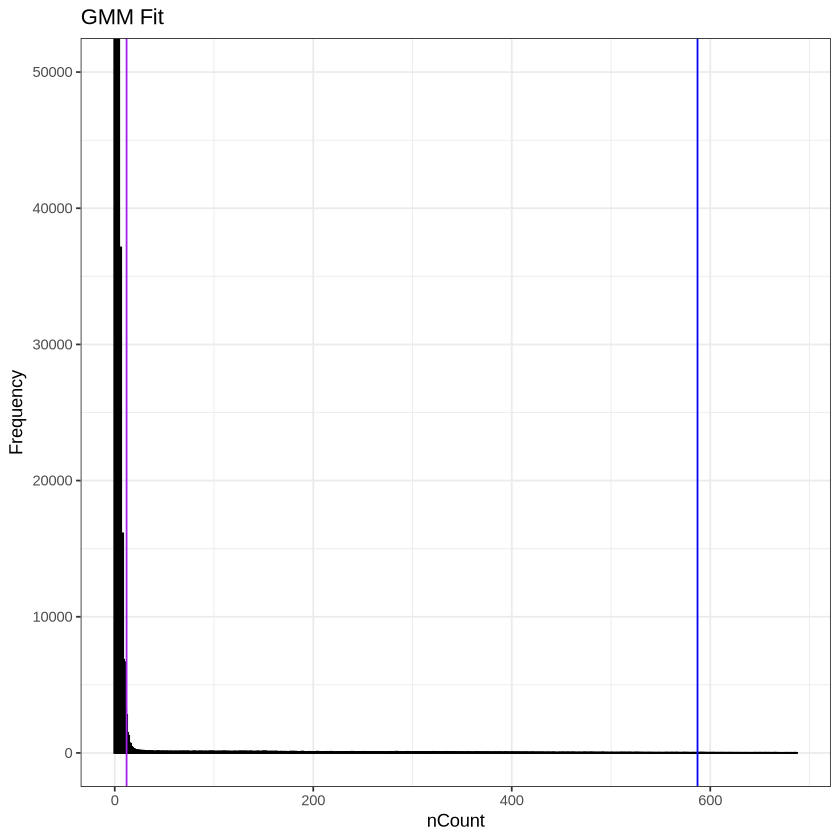

[1] "the number of cells detected is: "
[1] 1745
[1] "saving data"
Time difference of 51.08866 mins


2_Eo_DEG_G9_day5_VC



[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

[[4]]
NULL

[[5]]
NULL

[[6]]
NULL

[[7]]
NULL

[[8]]
NULL

[[9]]
NULL

[[10]]
NULL

[[11]]
Time difference of 1.393236 hours

[[12]]
NULL

[[13]]
Time difference of 51.08866 mins

[[14]]
NULL


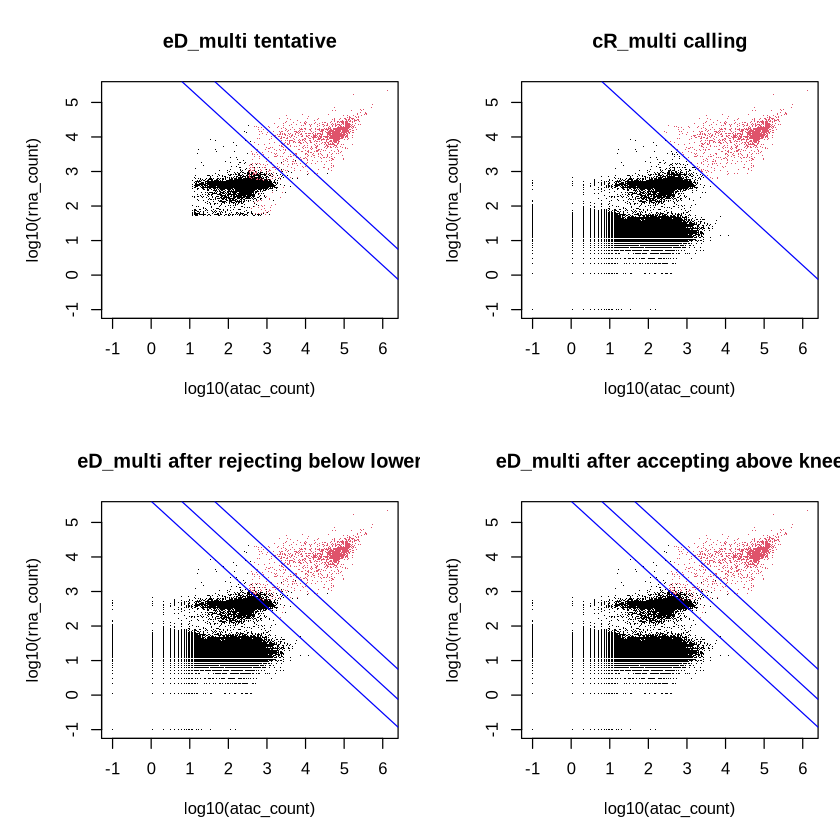

In [6]:
lapply(opts$samples, function(sample){
# for(sample in opts$samples){
    message(sample)
    
    io$outdir = sprintf('%s/multiome_reanalysis/results/data/%s/', io$home, sample)
    dir.create(io$outdir, showWarnings = F, recursive = T)
    
    if(!file.exists(paste0(io$outdir, 'barcodes.tsv'))){
        a = Sys.time()
        
        data_tmp = sprintf('%s/%s/outs/unfiltered_feature_bc_matrix/', io$datadir, sample)
        barcodes = fread(sprintf('%s/barcodes.tsv.gz', data_tmp), header = F)
        features = fread(sprintf('%s/features.tsv.gz', data_tmp))
        matrix = readMM(gzfile((sprintf('%s/matrix.mtx.gz', data_tmp))))
        
        rownames(matrix) = features$V2
        colnames(matrix) = barcodes$V1
        
        eD.out <- emptydrops_multiome(count_matrix_rna=matrix[grep('Gene Expression', features$V3),], 
                                      count_matrix_atac=matrix[grep('Peaks', features$V3),])
        
        print("the number of cells detected is: ")
        print(sum(eD.out$FDR_multi<0.001 & ! is.na(eD.out$FDR_multi)))
        
        eD.out = as.data.table(eD.out)
        cells_keep = eD.out[FDR_multi<0.001 & ! is.na(FDR_multi), Row.names]
        
        matrix_cells = matrix[, as.character(cells_keep)]
        rownames(matrix_cells) = NULL
        colnames(matrix_cells) = NULL
    
        print('saving data')
        writeMM(as(matrix_cells, 'CsparseMatrix'), paste0(io$outdir, 'matrix.mtx'))
        fwrite(features, paste0(io$outdir, 'features.tsv'), sep = '\t', col.names = F)
        fwrite(barcodes[V1 %in% cells_keep], paste0(io$outdir, 'barcodes.tsv'), sep = '-', col.names = F)
    
        b = Sys.time()
        print(b-a)
    }
})

In [9]:
# Run scds on files

In [1]:
library(scds)
library(Seurat)
library(SingleCellExperiment)
library(scuttle)

Warning message:
“package ‘Seurat’ was built under R version 4.4.2”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.4.2”
‘SeuratObject’ was built with package ‘Matrix’ 1.7.2 but the current
version is 1.7.3; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘SingleCellExperiment’ was built under R version 4.4.2”
Loading required package: SummarizedExperiment

Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.4.2”
Loading required package: MatrixGenerics

Warning message:
“package ‘MatrixGenerics’ was built under R version 4.4.2”
Loading required package: matrixStats

Warning message:
“package ‘matrixStats’ was built under R versio

In [8]:
sample = opts$samples[1]

In [ ]:
# for(sample in opts$samples){
    message(sample)
    
    io$outdir = sprintf('%s/multiome_reanalysis/results/data/%s/', io$home, sample)
    
    if(!file.exists(paste0(io$outdir, 'metadata_with_doublets.txt.gz'))){
        a = Sys.time()
        
        data_tmp = io$outdir
        barcodes = fread(sprintf('%s/barcodes.tsv', data_tmp), header = F)
        features = fread(sprintf('%s/features.tsv', data_tmp))
        matrix = readMM(gzfile((sprintf('%s/matrix.mtx', data_tmp))))
        
        rownames(matrix) = features$V2
        colnames(matrix) = barcodes$V1

        matrix = matrix[features[V3 == 'Gene Expression', V2], ]
        rownames(matrix) = make.names(rownames(matrix), unique = T)
        seurat <- CreateSeuratObject(matrix)
        
        # Add mitochondrial percenatge
        seurat[["mitochondrial_percent_RNA"]] <- PercentageFeatureSet(seurat, pattern = "^mt") %>% round(2)
        
        # Add ribosomal RNA content
        ribo.genes <- grep(pattern = "^Rp[l|s]", x = rownames(seurat), value = TRUE)
        seurat[["ribosomal_percent_RNA"]] <- PercentageFeatureSet(seurat, features = ribo.genes) %>% round(2)
                
        sce = SingleCellExperiment(list(counts = matrix))
        sce = logNormCounts(sce)
        colData(sce) = seurat@meta.data %>% DataFrame
        sce = sce[, colData(sce)$mitochondrial_percent_RNA < 5]
        
        sce <- cxds_bcds_hybrid(sce[1:1000, 1:100], estNdbl=TRUE)
        
        dt <- colData(sce) %>%
          .[,c("sample","cxds_score", "bcds_score", "hybrid_score")] %>%
          as.data.frame %>% tibble::rownames_to_column("cell") %>% as.data.table %>%
          .[,c("cxds_score","bcds_score","hybrid_score"):=list(round(cxds_score,2),round(bcds_score,2),round(hybrid_score,2))]  
        
        fwrite(dt, file.path(io$outdir, '/metadata_with_doublets.txt.gz', sep="\t", na="NA", quote=F))

        b = Sys.time()
        print(b-a)
}

In [16]:
        sce = SingleCellExperiment(list(counts = matrix))


In [20]:
counts(sce) = as(counts(sce), 'dgCMatrix')

In [1]:
library(SingleCellExperiment)
library(data.table)
library(Matrix)
library(Seurat)
library(ggplot2)
library(dplyr)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges

In [2]:
io = list()
io$home = '/rds/project/rds-SDzz0CATGms/users/bt392/'

io$datadir = sprintf('%s/09_Eomes_invitro_blood/original/', io$home)

In [3]:
opts = list()
opts$samples <- c(
  # first batch
  "rv_eo_deg_day3_5_control",
  "rv_eo_deg_day3_5_dtag",
  "rv_eo_deg_day4_5_control",
  "rv_eo_deg_day4_5_dtag",
  "rv_eo_deg_day4_control",
  "rv_eo_deg_day4_dtag",

  # second batch
  "1A_Eo_DEG_G9_day3",
  "1B_Eo_DEG_G9_day3",
  "2_Eo_DEG_G9_day3_5_dTAG",
  "2_Eo_DEG_G9_day3_5_VC",
  "2_Eo_DEG_G9_day4_dTAG",
  "2_Eo_DEG_G9_day4_VC",
  "2_Eo_DEG_G9_day5_dTAG",
  "2_Eo_DEG_G9_day5_VC"
)

In [4]:
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 42

In [13]:
library(future)
plan("multicore", workers = 42)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

In [4]:
matrix_list = parallel::mclapply(opts$samples, function(sample){ 
    
    io$outdir = sprintf('%s/multiome_reanalysis/results/data/%s/', io$home, sample)
        a = Sys.time()
        
        data_tmp = io$outdir
        barcodes = fread(sprintf('%s/barcodes.tsv', data_tmp), header = F)
        features = fread(sprintf('%s/features.tsv', data_tmp))
        matrix = readMM(gzfile((sprintf('%s/matrix.mtx', data_tmp))))
        
        rownames(matrix) = features$V2
        colnames(matrix) = paste0(sample, '#', barcodes$V1)

        matrix = matrix[features[V3 == 'Gene Expression', V2], ]
        rownames(matrix) = make.names(rownames(matrix), unique = T)
        return(matrix)
        
        b = Sys.time()
        print(b-a)
}, mc.cores = 12)

In [5]:
matrix_big = do.call('cbind', matrix_list)

In [6]:
rownames(matrix_big) = make.names(rownames(matrix_big), unique = T)


In [7]:
summary(duplicated(colnames(matrix_big)))

   Mode   FALSE 
logical   75784 

In [8]:
pbmc <- CreateSeuratObject(counts = matrix_big, project = "pbmc3k", min.cells = 0, min.features = 0)

In [9]:
pbmc

An object of class Seurat 
32285 features across 75784 samples within 1 assay 
Active assay: RNA (32285 features, 0 variable features)

In [14]:
        # Add mitochondrial percenatge
        pbmc[["mitochondrial_percent_RNA"]] <- PercentageFeatureSet(pbmc, pattern = "^mt") %>% round(2)
        
        # Add ribosomal RNA content
        ribo.genes <- grep(pattern = "^Rp[l|s]", x = rownames(pbmc), value = TRUE)
        pbmc[["ribosomal_percent_RNA"]] <- PercentageFeatureSet(pbmc, features = ribo.genes) %>% round(2)

pbmc <- NormalizeData(pbmc, normalization.method = "LogNormalize", scale.factor = 10000)
pbmc <- FindVariableFeatures(pbmc, selection.method = "vst", nfeatures = 4000)
all.genes <- rownames(pbmc)
pbmc <- ScaleData(pbmc, features = all.genes)
pbmc <- RunPCA(pbmc, features = VariableFeatures(object = pbmc))
pbmc <- FindNeighbors(pbmc, dims = 1:15)
pbmc <- FindClusters(pbmc, resolution = 0.7)

Centering and scaling data matrix

PC_ 1 
Positive:  Camk1d, Phlda2, Tmsb10, Fth1, Tuba1a, Ctla2a, Mt1, Tmsb4x, Xlr5a, Mt2 
	   Cfl1, Gchfr, Lrp1b, Gm32916, Tas1r1, Bnip3, Gal, Krt8, Ifitm3, Adam2 
	   Pyy, Olfr1369.ps1, Spin2c, S100a6, Crip1, Krt19, Nmb, Dqx1, Ikzf3, Olfr655 
Negative:  Gpc6, Magi1, Auts2, Tcf12, Akt3, Exoc4, Pard3, Ext1, Dlg1, Diaph2 
	   Ptprg, Tcf4, Kcnq1ot1, Setbp1, Large1, Msi2, Mbd5, Pbx1, Grip1, Jmjd1c 
	   Fbxl17, Arl15, Zfp407, Tenm3, Mid1, Pbx3, Tbc1d5, Sbf2, Dst, Klf12 
PC_ 2 
Positive:  Ppp4r4, Fst, Magi2, Cdh1, Dab1, T, Pid1, L1td1, Kcnj3, Tdgf1 
	   Nrxn1, Epcam, Fgf8, Pou5f1, Gldc, Esrp1, Kcnh8, Cldn7, Xkr4, X1700019D03Rik 
	   Epha1, Igfbp2, Nfasc, Pim2, Tmem200a, Gria4, Igfbp3, Fgf5, Fras1, Tdrd5 
Negative:  Igf2, Airn, Unc5c, Tbx20, Pcgf5, Tbx4, Plac1, Sox6, Nrp1, Fbn2 
	   Zeb1, Igfbp5, Peg10, Igf2r, Sfrp1, Vcan, Magi3, Vegfc, Col1a1, Cdkn1c 
	   Slc38a4, Tgfb2, Gm47071, Adam12, Mllt3, Pitx1, Cntn4, Igsf11, C430049B03Rik, Morc4 
PC_ 3 
Positive:  Co

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 75784
Number of edges: 2113927

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8999
Number of communities: 16
Elapsed time: 16 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


In [16]:
pbmc <- RunUMAP(pbmc, dims = 1:15, verbose = F)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”


In [17]:
umap = as.data.table(pbmc@reductions$umap@cell.embeddings, keep.rownames = T)

In [18]:
pbmc@meta.data$logcount = log10(pbmc@meta.data$nCount_RNA)
pbmc@meta.data$logfeature = log10(pbmc@meta.data$nFeature_RNA)


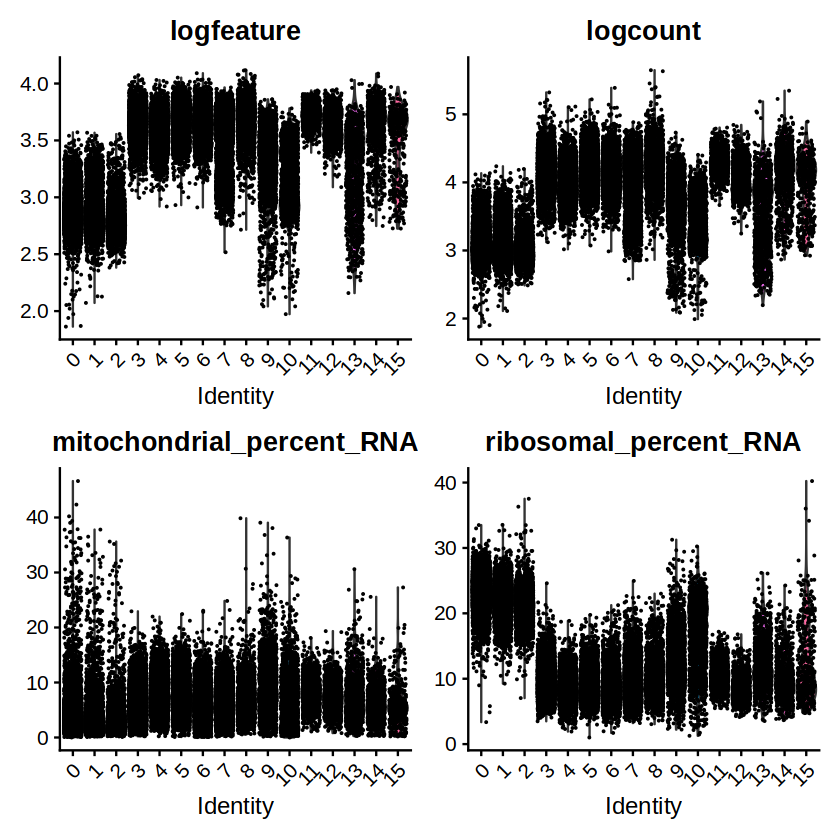

In [19]:
# Visualize QC metrics as a violin plot
VlnPlot(pbmc, features = c("logfeature", "logcount", "mitochondrial_percent_RNA", 'ribosomal_percent_RNA'), ncol = 2)

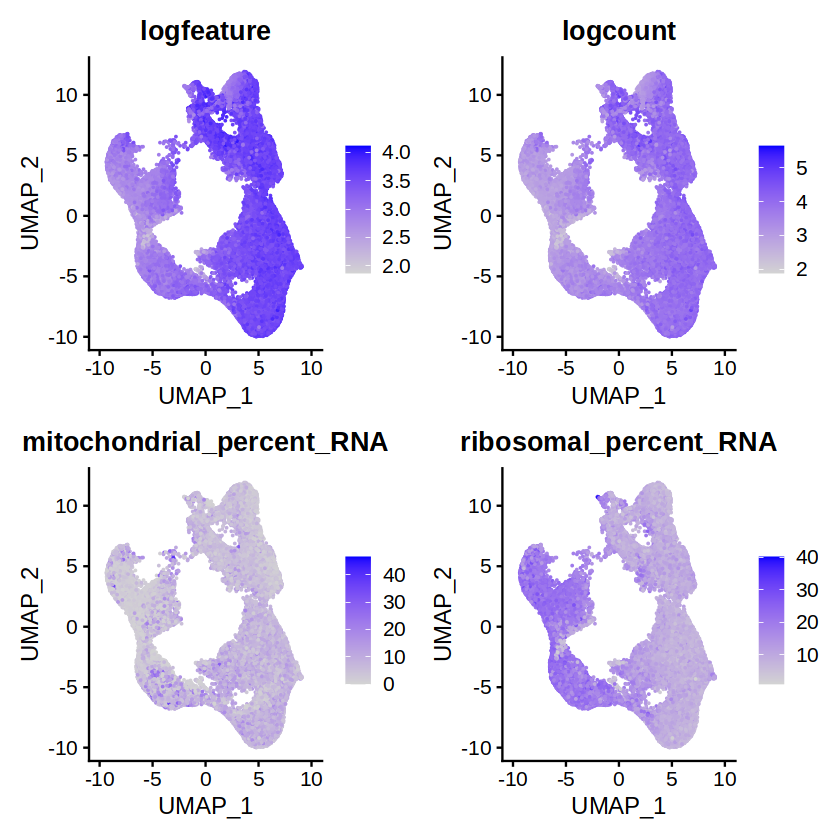

In [20]:
FeaturePlot(
  pbmc,
  c("logfeature", "logcount", "mitochondrial_percent_RNA", 'ribosomal_percent_RNA'))

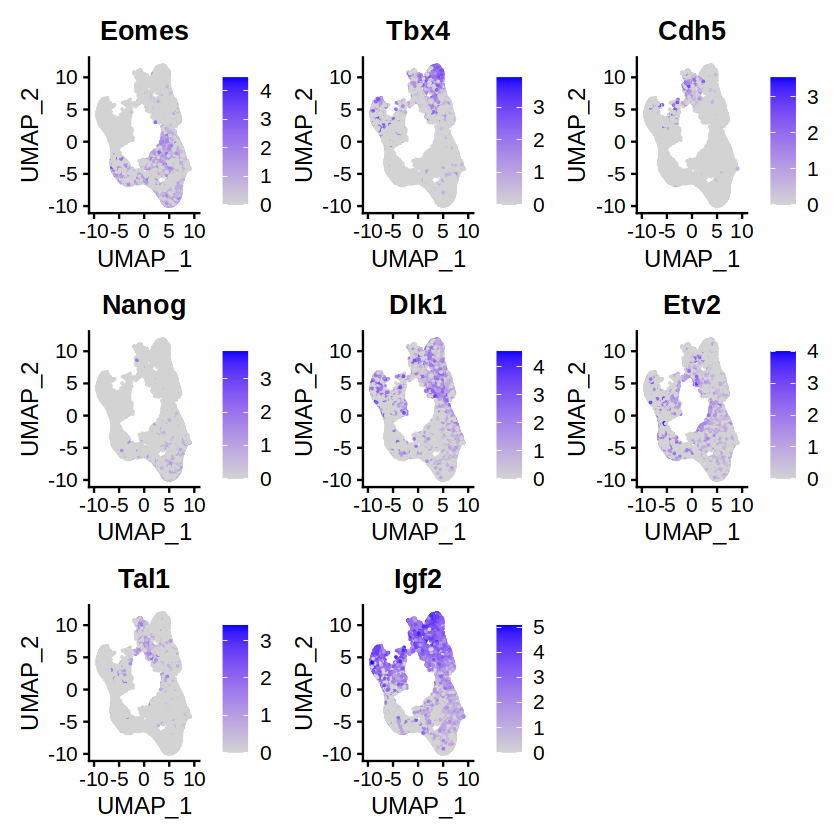

In [21]:
FeaturePlot(
  pbmc,
  c('Eomes', 'Tbx4', 'Cdh5', 'Nanog', 'Dlk1', 'Etv2', 'Tal1', 'Igf2'))

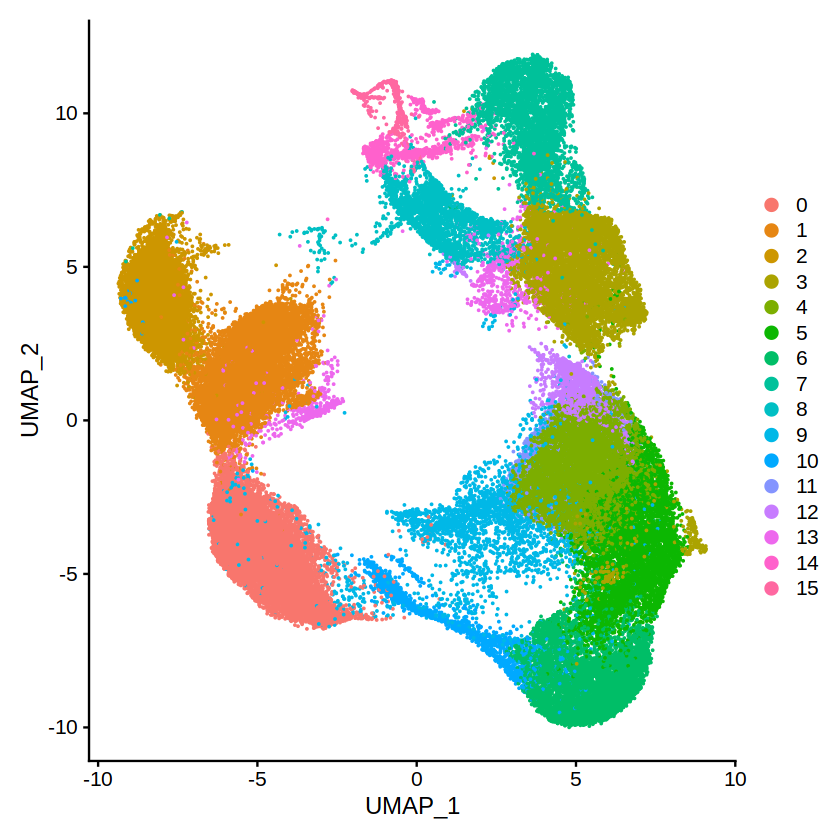

In [22]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters
DimPlot(pbmc, reduction = "umap")

In [ ]:
# find markers for every cluster compared to all remaining cells, report only the positive
# ones
pbmc.markers <- FindAllMarkers(pbmc, only.pos = TRUE)
pbmc.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1)

In [10]:
# Add mitochondrial percenatge
pbmc[["mitochondrial_percent_RNA"]] <- PercentageFeatureSet(pbmc, pattern = "^mt") %>% round(2)

# Add ribosomal RNA content
ribo.genes <- grep(pattern = "^Rp[l|s]", x = rownames(pbmc), value = TRUE)
pbmc[["ribosomal_percent_RNA"]] <- PercentageFeatureSet(pbmc, features = ribo.genes) %>% round(2)

pbmc <- NormalizeData(pbmc, normalization.method = "LogNormalize", scale.factor = 10000)
pbmc <- FindVariableFeatures(pbmc, selection.method = "vst", nfeatures = 4000)

In [11]:
vargenes = VariableFeatures(pbmc)

In [ ]:

pbmc <- ScaleData(pbmc, features = vargenes, vars.to.regress = c('nCount_RNA', 'nFeature_RNA'))
pbmc <- RunPCA(pbmc, features = VariableFeatures(object = pbmc))
pbmc <- RunUMAP(pbmc, dims = 1:15, verbose = F)

Regressing out nCount_RNA, nFeature_RNA



In [ ]:
FeaturePlot(
  pbmc,
  c('Eomes', 'Tbx4', 'Cdh5', 'Nanog', 'Dlk1', 'Etv2', 'Tal1', 'Igf2'))

In [ ]:
# note that you can set `label = TRUE` or use the LabelClusters function to help label
# individual clusters
DimPlot(pbmc, reduction = "umap")

In [ ]:
# find markers for every cluster compared to all remaining cells, report only the positive
# ones
pbmc.markers <- FindAllMarkers(pbmc, only.pos = TRUE)
pbmc.markers %>%
    group_by(cluster) %>%
    dplyr::filter(avg_log2FC > 1)

In [50]:
meta = eD.out[Row.names %in% cells_keep]

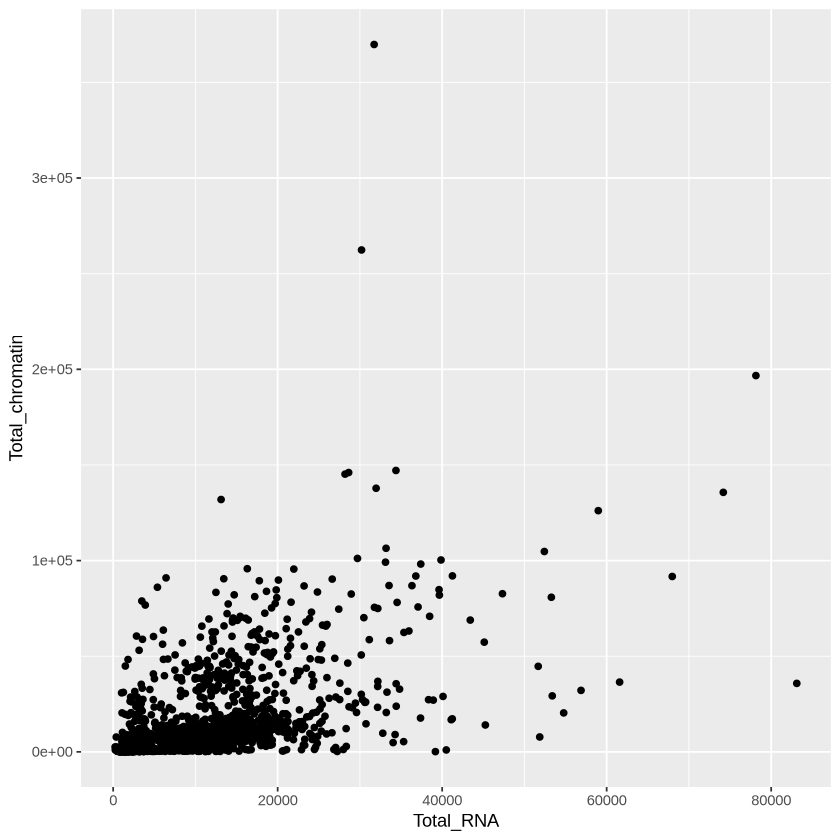

In [52]:
ggplot(meta, aes(Total_RNA, Total_chromatin)) + 
    geom_point()